## DM-54247 Investigate 2026-02-13 RB model

Eric Bellm, 2026-02-23



In [112]:
import lsst.afw.display
import lsst.daf.butler
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.visualization as aviz
from matplotlib import cm
from IPython.display import Image, display, HTML
import ipywidgets as widgets

In [10]:
collection = 'LSSTCam/prompt/output-2026-02-22'
#collection = 'u/elhoward/DM-52372/w33_drp/template_coadd-QC/test2'
#collection = 'u/elhoward/DM-52372/w33_drp/template_coadd-QC/test_2396'

butler = lsst.daf.butler.Butler("embargo", collections=collection)

https://usdf-rsp.slac.stanford.edu/portal/app/onlinehelp/#id=visualization.fitsViewer

In [22]:

#sc = SkyCoord('4h19m54.62s -48d24m12.8s', unit=('hourangle','deg'))
#sc = SkyCoord('4h19m57.58s -48d25m20.8s', frame='icrs') # test edges
sc = SkyCoord('4h14m01.19s -48d22m45.9s', frame='icrs') # test grid
ra = sc.ra.degree
dec = sc.dec.degree
band = "'z'"

In [16]:
refs = butler.query_datasets('difference_image')
#refs = butler.query_datasets('difference_image',  where=f'visit_detector_region.region OVERLAPS POINT({ra}, {dec}) and band={band}')

In [17]:
#refs = butler.query_datasets('initialPviSummary_metrics')

In [18]:
len(refs)

20000

In [29]:
exp = butler.get(refs[1])

In [20]:
exp.getInfo().getVisitInfo().getObject()

'lowdust, ddf_edfs_a'

In [21]:
exp.getInfo().getVisitInfo().getObservationReason()

'alert_edfs_a'

In [22]:
#exp.getInfo().getMetadata()

In [42]:
display1 = lsst.afw.display.Display(backend='firefly',frame=1)
display2 = lsst.afw.display.Display(backend='firefly', frame=2)

In [91]:
ref = refs[14]
dataId = ref.dataId
dataId

{instrument: 'LSSTCam', detector: 124, visit: 2026022200100, band: 'z', day_obs: 20260222, physical_filter: 'z_20'}

In [92]:
#dataId = {'instrument': 'LSSTCam', 'detector': 61, 'visit': 2025110400330}

In [102]:
dia_source= butler.get('dia_source_detector', dataId)
difference =  butler.get('difference_image', dataId)
template =  butler.get('template_detector', dataId)
science = butler.get('preliminary_visit_image', dataId)

In [94]:
dia_source['reliability']

0     0.185203
1     0.287128
2     0.177770
3     0.111895
4     0.111170
5     0.108301
6     0.253204
7     0.194667
8     0.101916
9     0.311423
10    0.176231
11    0.106179
12    0.122970
13    0.283951
14    0.310480
Name: reliability, dtype: float32

In [95]:
#display1.image(template)

display2.image(difference)
#display2.centroids(dia_source_unfiltered, size=10, ctype='blue')
for idx,row in dia_source.iterrows():
    display2.dot('o',row['x'], row['y'], size=10, ctype='red')

In [98]:
# steal some crappy old code

In [106]:
def get_cutouts(row, science, difference, template, size=lsst.geom.Extent2I(30, 30)):
    """Return a cutout for this dataId at the given source location."""
    center=lsst.geom.SpherePoint(row['ra'], row['dec'], lsst.geom.degrees)
    return science.getCutout(center, size), difference.getCutout(center, size), template.getCutout(center, size)

In [143]:
def plot_cutout(science, difference, template, title = None, output=None):
    """Plot the cutouts for a source in one image.
    """
    Qst=15 #Q for Science and Template
    sst=4 #Stretch for Science and Template
    Qd=5 #Q for Difference
    sd=50 #Stretch for Difference
    asinst=0.01
    asind=0.7

    def do_one(ax, data, name):
        interval = aviz.ZScaleInterval()

        if name == 'Difference':
            norm = aviz.ImageNormalize(data,  stretch=aviz.LinearStretch())
        else:
            norm = aviz.ImageNormalize(data, interval=interval, stretch=aviz.AsinhStretch(a=0.01))
        ax.imshow(data, cmap=cm.bone, interpolation="none")
        ax.axis('off')
        ax.set_title(name)

    
    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 3), constrained_layout=True)
    do_one(ax1, template.image.array, "Template")
    do_one(ax2, science.image.array, "Science")
    do_one(ax3, difference.image.array, "Difference")
    f.suptitle(title, va='baseline')
    plt.tight_layout()

    if output is not None:
        plt.savefig(output, bbox_inches="tight")
        plt.close()


/tmp/ipykernel_652/1683180411.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


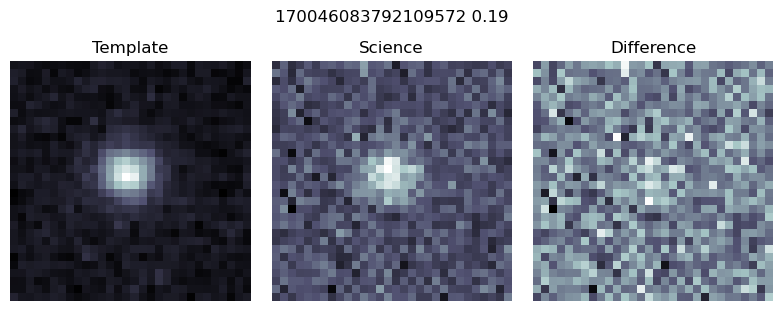

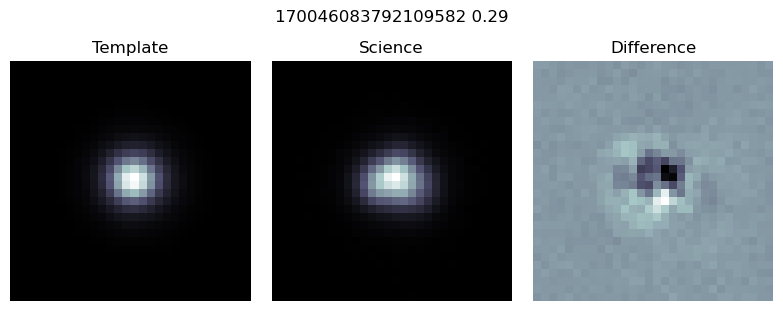

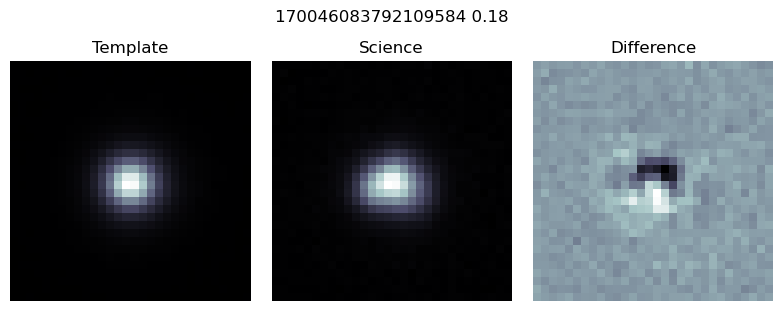

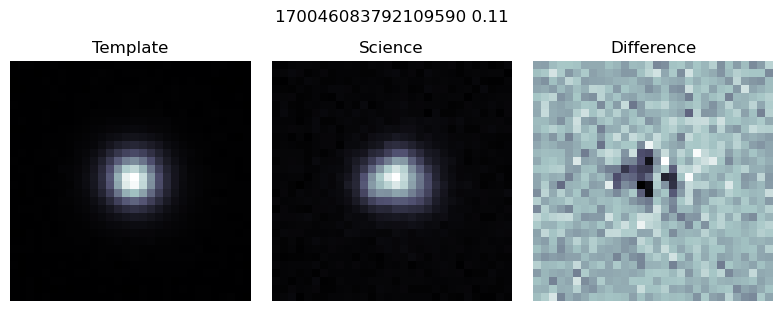

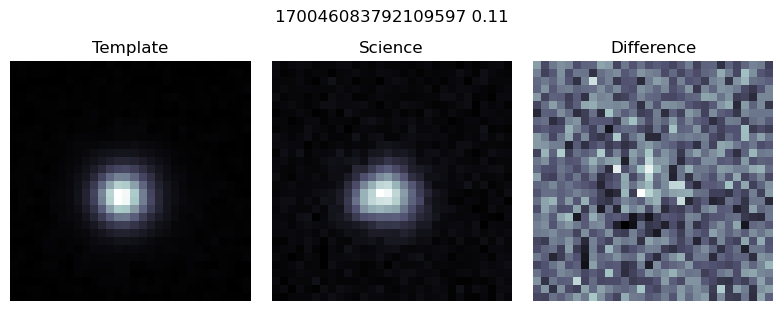

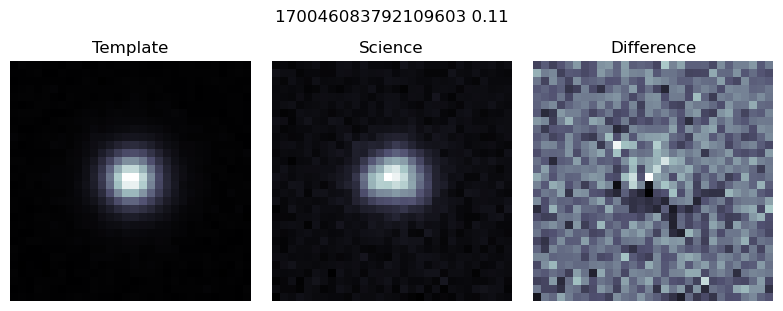

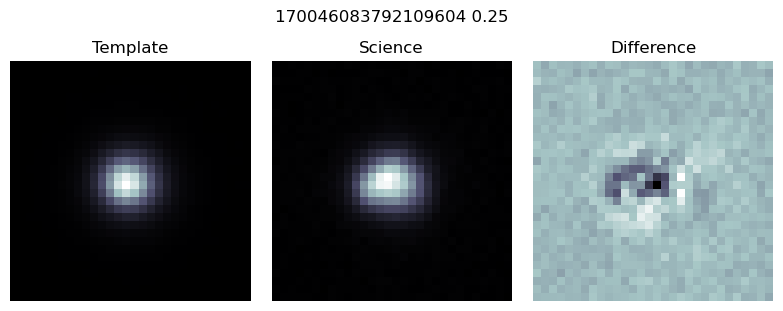

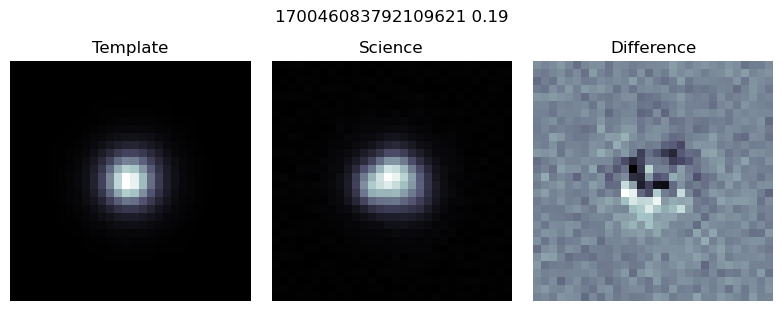

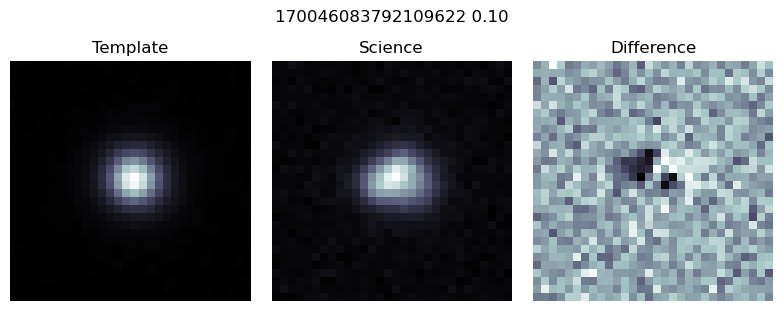

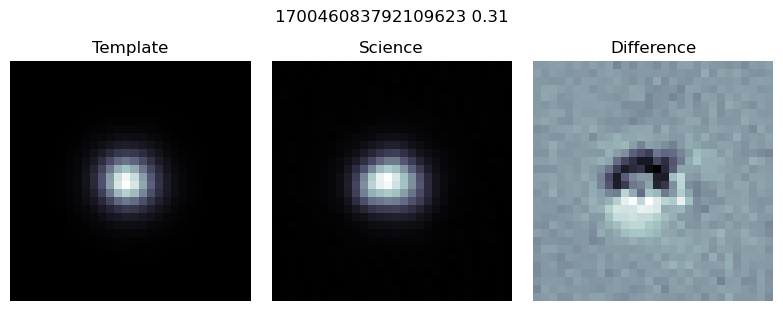

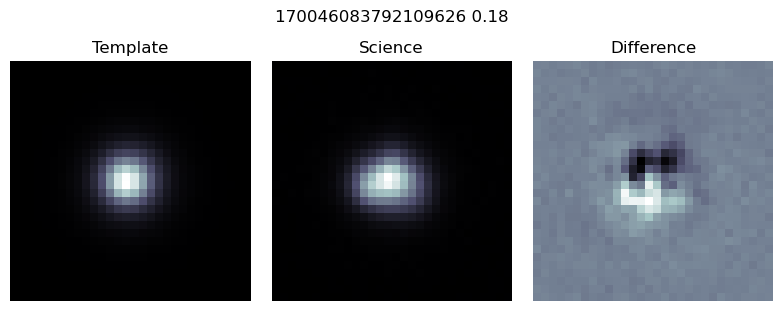

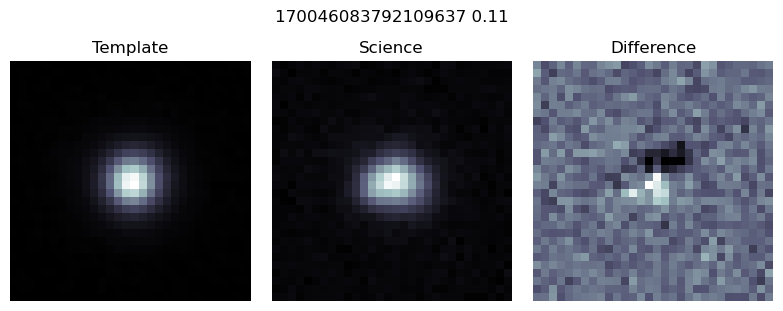

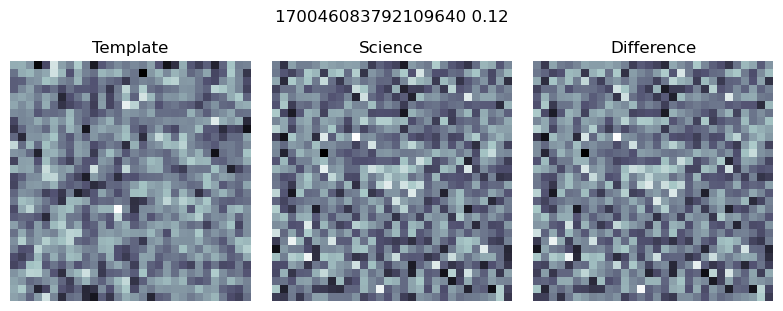

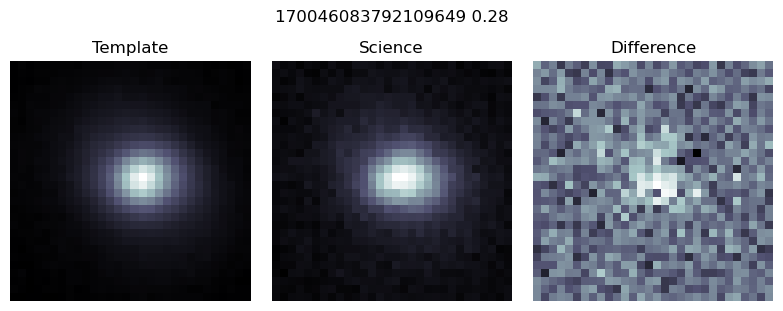

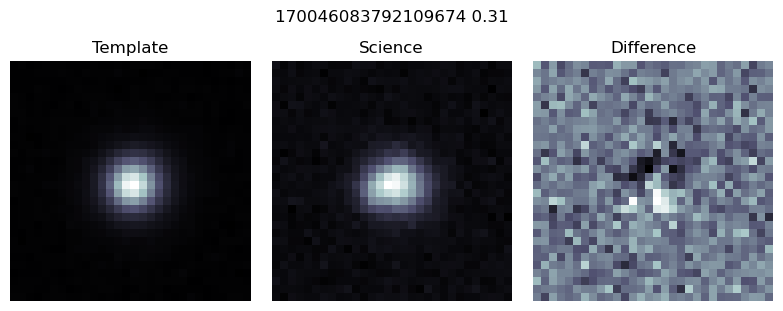

In [144]:
for idx,row in dia_source.iterrows():
    cutout_science, cutout_diff, cutout_tmpl = get_cutouts(row, science, difference, template)
    title = f"{row['diaSourceId']} {row['reliability']:0.2f}"
    plot_cutout(cutout_science, cutout_diff, cutout_tmpl, title = title)

In [36]:

difference.mask.getMaskPlaneDict()

{'BAD': 0,
 'CLIPPED': 11,
 'CR': 3,
 'CROSSTALK': 12,
 'DETECTED': 5,
 'DETECTED_NEGATIVE': 6,
 'EDGE': 4,
 'HIGH_VARIANCE': 13,
 'INEXACT_PSF': 14,
 'INJECTED': 15,
 'INJECTED_TEMPLATE': 16,
 'INTRP': 2,
 'ITL_DIP': 17,
 'NOT_DEBLENDED': 18,
 'NO_DATA': 8,
 'REJECTED': 19,
 'SAT': 1,
 'SAT_TEMPLATE': 20,
 'SENSOR_EDGE': 21,
 'STREAK': 10,
 'SUSPECT': 7,
 'UNMASKEDNAN': 22,
 'VIGNETTED': 9}

In [52]:
display3 = lsst.afw.display.Display(backend='firefly', frame=3)

In [53]:
template_coadd = butler.get('template_coadd', {'instrument': 'LSSTComCam', 'tract':2397, 'patch':48, 'band':'r', 'skymap':'lsst_cells_v1'})
display3.image(template_coadd)

In [73]:
butler.get('rewarpTemplate_config', dataId) 

lsst.ip.diffim.getTemplate.GetTemplateConfig(saveLogOutput=True, templateBorderSize=20, warp={'warpingKernelName': 'lanczos3', 'maskWarpingKernelName': 'bilinear', 'interpLength': 100, 'cacheSize': 100000, 'growFullMask': 16}, coaddPsf={'cacheSize': 100000, 'warpingKernelName': 'lanczos3'}, connections={'bbox': 'preliminary_visit_image.bbox', 'wcs': 'preliminary_visit_image.wcs', 'skyMap': 'skyMap', 'coaddExposures': 'template_coadd', 'template': 'template_detector', 'coaddName': 'goodSeeing', 'warpTypeSuffix': '', 'fakesType': ''})

In [57]:
refs = butler.query_datasets('template_coadd')

In [58]:
len(refs)

5418